In [1]:
!pip install -q ultralytics tensorboard roboflow
!yolo settings tensorboard=True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralyt

In [2]:
import os
import shutil
import yaml
from PIL import Image
from kaggle_secrets import UserSecretsClient
from roboflow import Roboflow

In [3]:
user_secrets = UserSecretsClient()
key_data = user_secrets.get_secret("dataset_facemask")

### 1. download dataset from roboflow

In [4]:
rf = Roboflow(api_key=key_data)
project = rf.workspace("ammar-workspace").project("face-mask-detection-2-oezvq")
version = project.version(4)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Face-Mask-Detection-2-4 in yolov8:: 100%|██████████| 9964/9964 [00:01<00:00, 8993.17it/s] 


### 2. Count Labels from train dataset

In [5]:
def count_labels(labels_train_path):
    count_incorret = 0
    count_mask = 0
    count_withoutmask = 0
    
    for txt in os.listdir(labels_train_path):
        txt_path = os.path.join(labels_train_path, txt)
        
        with open(txt_path, 'r') as f:
            data = f.readlines()
            for line in data:
                if line[0] == '0': count_incorret += 1
                if line[0] == '1': count_mask += 1
                if line[0] == '2': count_withoutmask += 1
    
    print("count_incorret:",count_incorret)
    print("count_mask:",count_mask)
    print("count_withoutmask:",count_withoutmask)

In [6]:
labels_train_path = "/kaggle/working/Face-Mask-Detection-2-4/train/labels"
count_labels(labels_train_path)

count_incorret: 867
count_mask: 4311
count_withoutmask: 2225


### 3. Augmentation for labels small (incorrect mask)

In [7]:
img_train_path = "/kaggle/working/Face-Mask-Detection-2-4/train/images"

n_agu = 3
for agu in range(n_agu):
    for txt in os.listdir(labels_train_path):
        if not txt.endswith(".txt"):
            continue
    
        with open (os.path.join(labels_train_path, txt) , 'r') as f:
            lines = f.readlines()
            
        if len(lines) == 1 and lines[0].startswith("0"):
            old_path_labels = os.path.join(labels_train_path, txt)
            new_name_label = f"agu{agu}_" + txt
            new_path_labels = os.path.join(labels_train_path, new_name_label)
            shutil.copy2(old_path_labels, new_path_labels)

            old_img_name = txt.replace(".txt", ".jpg")
            new_img_name = new_name_label.replace(".txt", ".jpg")
            old_path_img = os.path.join(img_train_path, old_img_name)
            new_path_img = os.path.join(img_train_path, new_img_name)
            shutil.copy2(old_path_img, new_path_img)

In [8]:
labels_train_path = "/kaggle/working/Face-Mask-Detection-2-4/train/labels"
count_labels(labels_train_path)

count_incorret: 5725
count_mask: 4311
count_withoutmask: 2225


### 4. Custom data.yaml file

In [9]:
data_yaml_path = "/kaggle/working/Face-Mask-Detection-2-4/data.yaml"

with open(data_yaml_path, 'r') as f:
    data = f.read()
print(data)

names:
- Incorrect_Mask
- With_Mask
- Without_Mask
nc: 3
roboflow:
  license: CC BY 4.0
  project: face-mask-detection-2-oezvq
  url: https://universe.roboflow.com/ammar-workspace/face-mask-detection-2-oezvq/dataset/4
  version: 4
  workspace: ammar-workspace
test: ../test/images
train: ../train/images
val: ../valid/images



In [10]:
with open(data_yaml_path, 'r') as f:
    data = yaml.safe_load(f)
    
data["train"] = "/kaggle/working/Face-Mask-Detection-2-4/train/images"
data["val"] = "/kaggle/working/Face-Mask-Detection-2-4/valid/images"
data["test"] = "/kaggle/working/Face-Mask-Detection-2-4/test/images"

with open(data_yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

In [11]:
with open(data_yaml_path, 'r') as f:
    data = f.read()
print(data)

names:
- Incorrect_Mask
- With_Mask
- Without_Mask
nc: 3
roboflow:
  license: CC BY 4.0
  project: face-mask-detection-2-oezvq
  url: https://universe.roboflow.com/ammar-workspace/face-mask-detection-2-oezvq/dataset/4
  version: 4
  workspace: ammar-workspace
test: /kaggle/working/Face-Mask-Detection-2-4/test/images
train: /kaggle/working/Face-Mask-Detection-2-4/train/images
val: /kaggle/working/Face-Mask-Detection-2-4/valid/images



### 5. Training Model

In [12]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")  

model.train(
    epochs=200,
    data=data_yaml_path,
    lr0=0.01,
    batch=16,
    cls=1.8,
    optimizer='AdamW',
    imgsz=640,
    degrees=20,    
    device=[0, 1],
    verbose=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.8, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Face-Mask-Detection-2-4/data.yaml, degrees=20, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64,

E0000 00:00:1772285535.843336      65 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772285535.941476      65 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772285536.882968      65 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772285536.883008      65 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772285536.883012      65 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772285536.883015      65 computation_placer.cc:177] computation placer already registered. Please check linka

TensorBoard: Start with 'tensorboard --logdir /kaggle/working/runs/detect/train', view at http://localhost:6006/
Overriding model.yaml nc=80 with nc=3
Transferred 469/475 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1236.2±463.7 MB/s, size: 49.8 KB)
train: Scanning /kaggle/working/Face-Mask-Detection-2-4/train/labels... 8648 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8648/8648 1.5Kit/s 5.8s
train: New cache created: /kaggle/working/Face-Mask-Detection-2-4/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 794.3±430.5 MB/s, size: 49.1 KB)
val: Scanning /kaggle/working/Face-Mask-Detection-2-4/valid/

/usr/local/lib/python3.12/dist-packages/torch/jit/_trace.py:685: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /kaggle/working/runs/detect/train
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      3.52G      1.654      5.648      1.731          8        640: 100% ━━━━━━━━━━━━ 541/541 3.2it/s 2:48
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.7it/s 6.2s
                   all        732       1426      0.487      0.441      0.493      0.235

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      4.14G      1.451      4.302      1.554         10        640: 100% ━━━━━━━━━━━━ 541/541 3.3it/s 2:45
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 4.2it/s 5.5s
                   all        732       1426      0.753       0.66   

In [13]:
!yolo predict model="/kaggle/working/runs/detect/train/weights/best.pt" source="/kaggle/working/Face-Mask-Detection-2-4/test/images"

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs

image 1/454 /kaggle/working/Face-Mask-Detection-2-4/test/images/A_06_jpg.rf.12411a4c8233007c01947b7138c2c38f.jpg: 640x640 1 With_Mask, 37.0ms
image 2/454 /kaggle/working/Face-Mask-Detection-2-4/test/images/A_09_jpg.rf.c2edae1b3ed3a9d156c20d457ccf21a0.jpg: 640x640 1 Without_Mask, 36.9ms
image 3/454 /kaggle/working/Face-Mask-Detection-2-4/test/images/A_101_jpg.rf.8981cb04f4afb60dd676c4f8d25ede53.jpg: 640x640 1 Without_Mask, 36.9ms
image 4/454 /kaggle/working/Face-Mask-Detection-2-4/test/images/A_102_jpg.rf.bd324ccfb4386f314925ee7cf2651ef6.jpg: 640x640 1 With_Mask, 36.9ms
image 5/454 /kaggle/working/Face-Mask-Detection-2-4/test/images/A_103_jpg.rf.d331167d183564ddc8e17b39fda6a46f.jpg: 640x640 1 Without_Mask, 28.4ms
image 6/454 /kaggle/working/Face-Mask-Detection-2-4/test/images/A_110_jpg.rf.9f5e894c3a50d990991a46475872a3dc.jpg

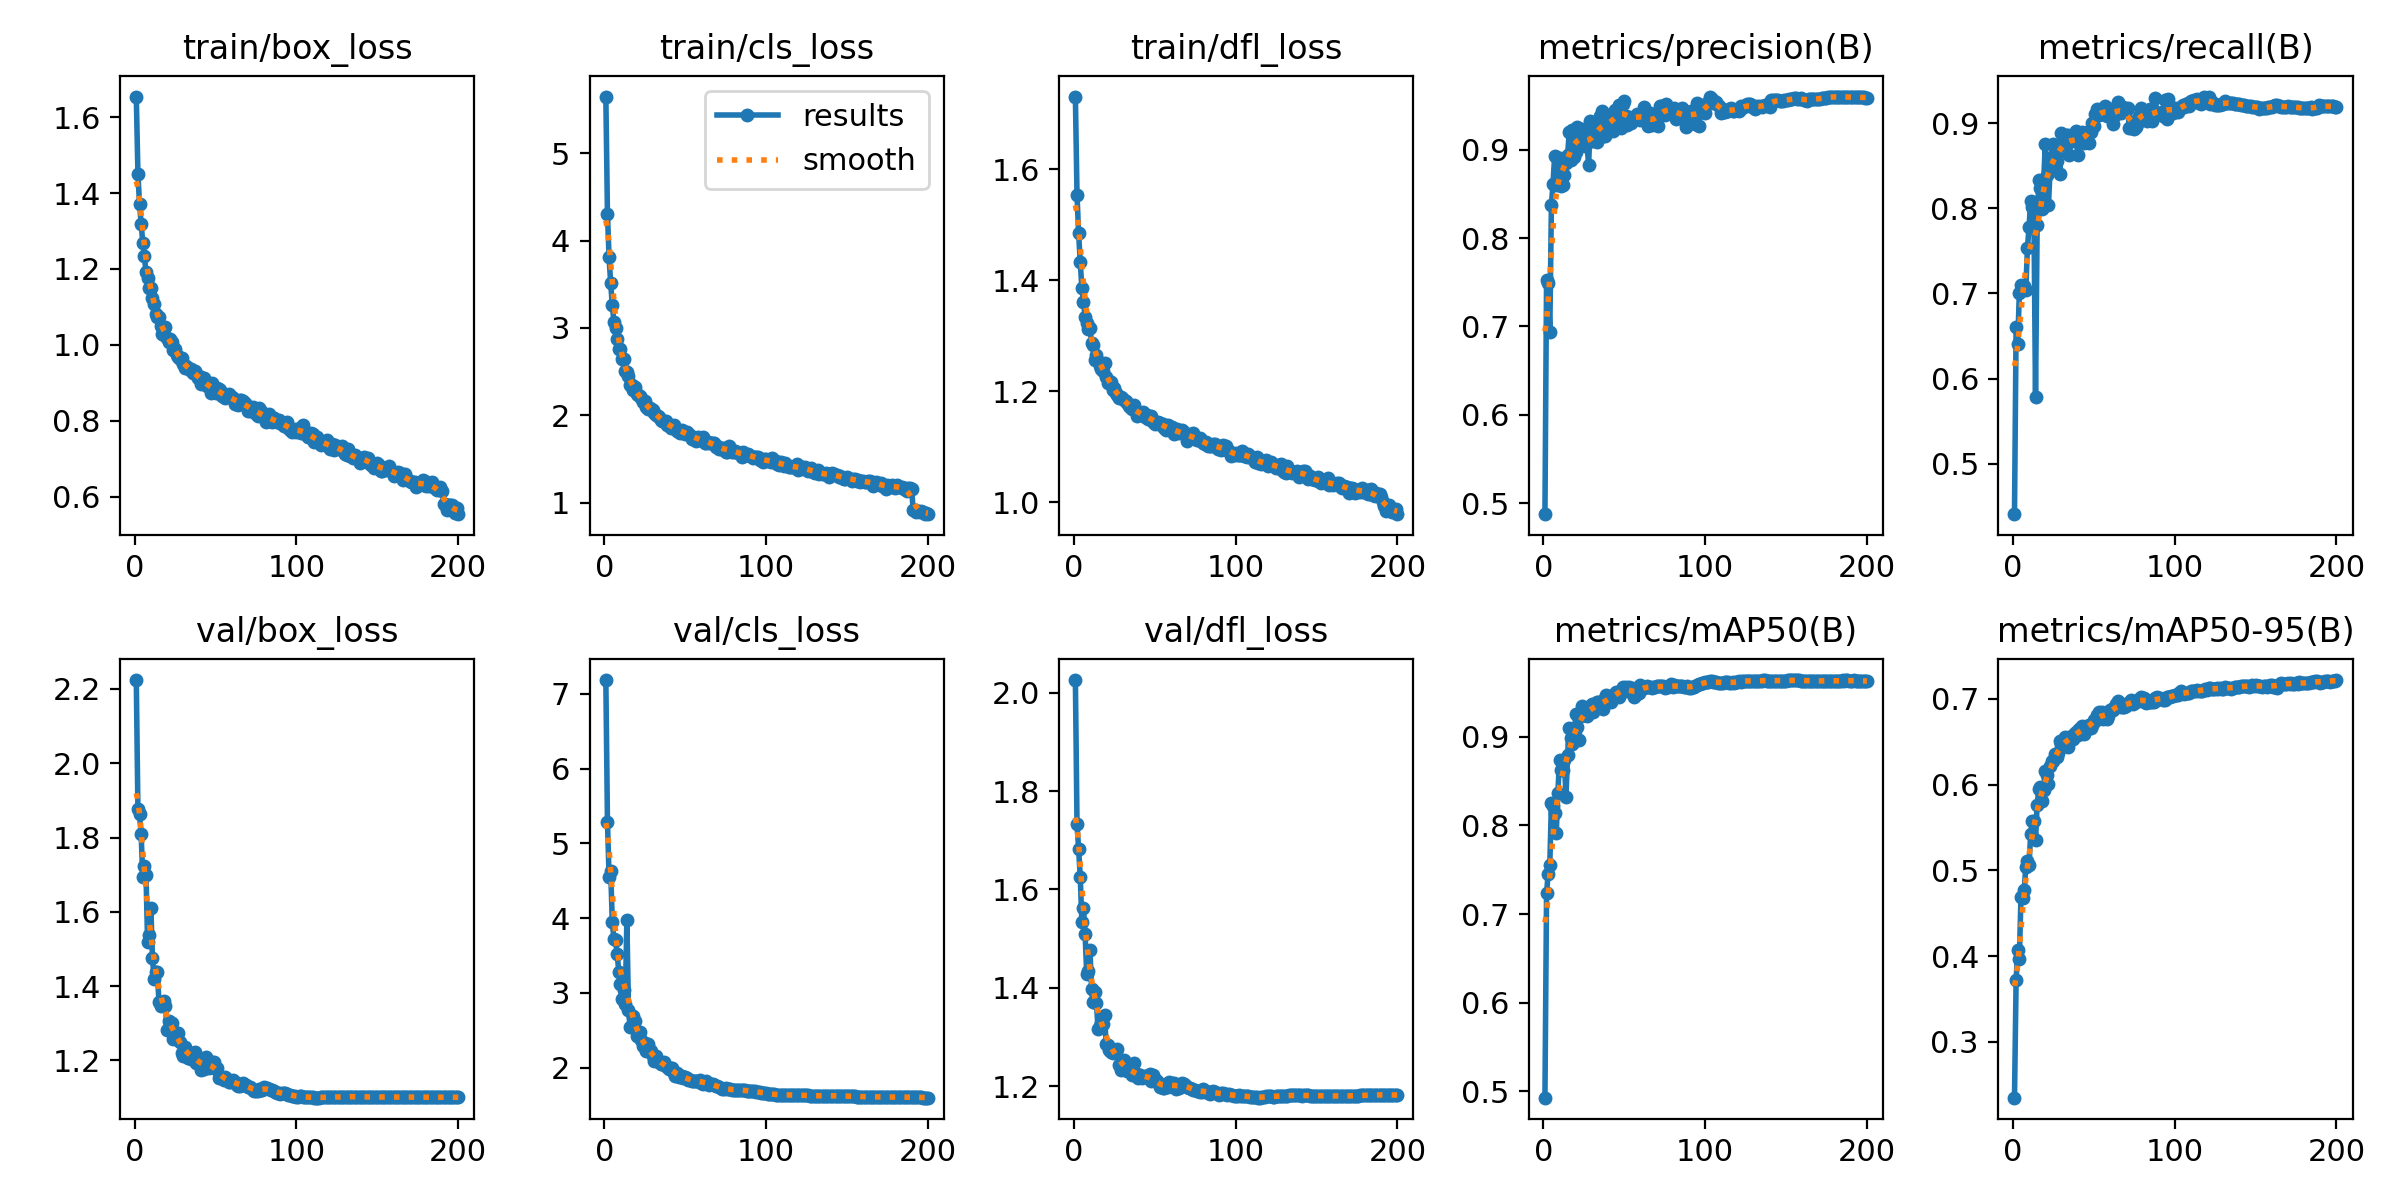

In [14]:
Image.open('/kaggle/working/runs/detect/train/results.png')

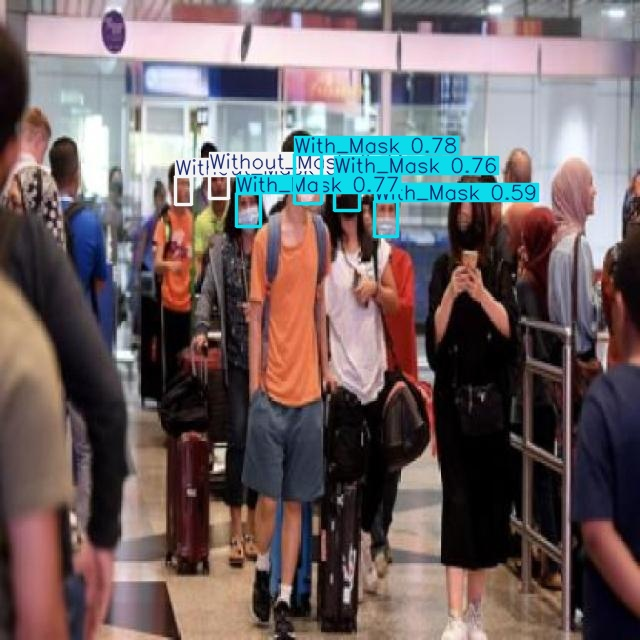

In [15]:
Image.open('/kaggle/working/runs/detect/predict/valv3-1060_jpg.rf.8046646da76eb0b1736e70afa55a1547.jpg')

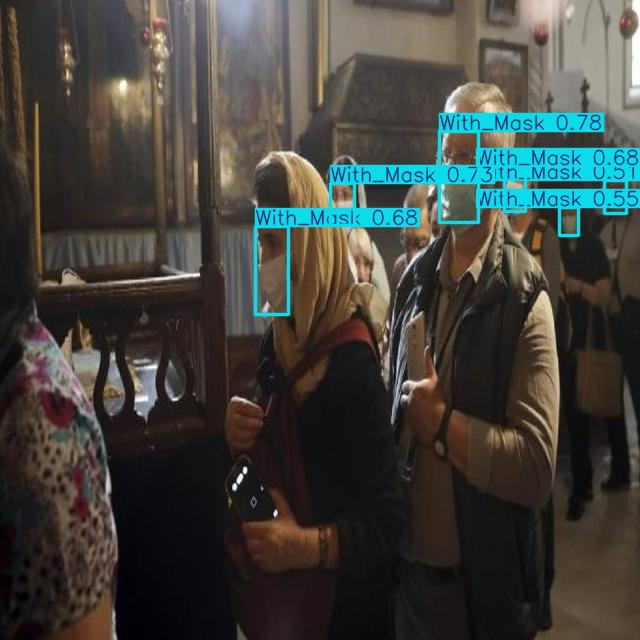

In [16]:
Image.open('/kaggle/working/runs/detect/predict/C_503_jpg.rf.77c83e80fac68dc40fb8389ed56cb481.jpg')

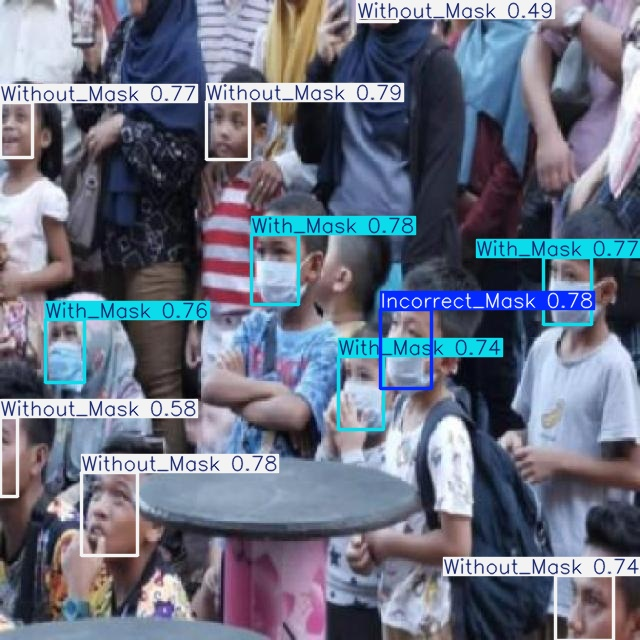

In [17]:
Image.open('/kaggle/working/runs/detect/predict/valv3-1262_jpg.rf.de5c34f22d571df5c007345aad93d98a.jpg')